In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
from matplotlib import rc

import seaborn as sns

def custom_grouping(index):
    return index // 1000

names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
names_latency=['time', 'latency', 'op2', 'write_size', 'op3']

In [19]:
cmr_zipf_9010_1M_bw = 98.39  # MiB/s
cmr_uniform_1M_bw = 81.05  # MiB/s
cmr_zipf_9010_4K_bw = 2.46  # MiB/s 
cmr_uniform_4K_bw = 1.26  # MiB/s

# Series colors hash
series_colors = {
    "hasmr": "#56B4E9",
    "dmhybrid": "#CC79A7",
    "hmhybrid": "#009E73",
    "cmr": "#E69F00",
    "hmls": "#0072B2"
}

# Reference line colors hash
ref_line_colors = {
    "PRE": "#000000",
    "POST": "#666666",
    "TIME": "#999999",
    "CMR": "#332288"
}

# Reference line styles hash
ref_line_styles = {
    "PRE": "-",
    "POST": "--",
    "TIME": ":",
    "CMR": "-."
}

In [20]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'fast2026/HM-Hybrid/1M/90-10-LBA/90Util/round1/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)

df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

In [21]:
# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576 #1MB
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]

/var/folders/2k/prv9ywh52sn57l626bl42pz40000gp/T/ipykernel_5016/3920337363.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[7491.90982398 7491.90982398 7491.90982398 7491.90982398 7491.90982398
 7491.90982398 7491.90982398 7491.90982398 7491.90982398 7491.90982398
 7491.90982398 7491.90982398 7491.90982398 7491.90982398 7491.90982398
 7491.90982398 7491.90982398 7491.90982398 7491.90982398 7491.90982398
 7491.90982398 7491.90982398 7491.90982398 7491.90982398 7491.90982398
 7491.90982398 7491.90982398 7491.90982398 7491.90982398 7491.90982398
 7491.90982398 7491.90982398 7491.90982398 7491.90982398 7491.90982398
 7491.90982398 7491.90982398 7491.90982398 7491.90982398 7491.90982398
 7491.90982398 7491.90982398 7491.90982398 7491.90982398 7491.90982398
 7491.90982398 7491.90982398 7491.90982398 7491.90982398 7491.90982398
 7491.90982398 7491.90982398 7491.90982398 7491.90982398 7491.90982398
 7491.90

46079


In [22]:
chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped.describe())
print(df_grouped.info())

             index  data_written_bytes  cumulative_gb
count  6963.000000         6963.000000    6963.000000
mean   3481.000000            6.617837      40.093490
std    2010.189295           28.622938       5.025548
min       0.000000            0.000000       0.071197
25%    1740.500000            0.315068      38.451278
50%    3481.000000            0.371748      40.746892
75%    5221.500000            0.466159      42.969788
max    6962.000000          207.007791      45.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6963 entries, 0 to 6962
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               6963 non-null   int64  
 1   data_written_bytes  6963 non-null   float64
 2   cumulative_gb       6963 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 163.3 KB
None


In [23]:
data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + ' MB/s'
avg_bw_str2 = str(round(average_mode2, 2)) + ' MB/s'

Average1: 1
Average2: 155


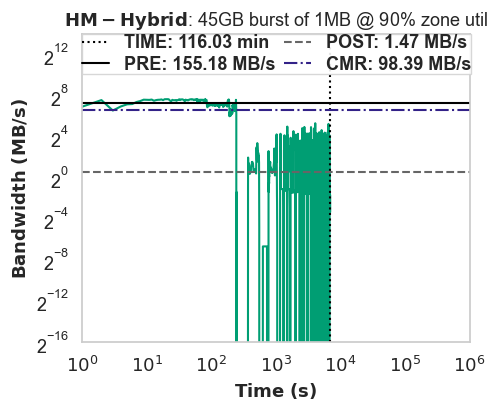

In [27]:
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped, color=series_colors['hmhybrid'], linewidth=1.5)
plt.title(r"$\bf{HM-Hybrid}$: 45GB burst of 1MB @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME: ' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=average_mode2, color=ref_line_colors['PRE'], linestyle=ref_line_styles['PRE'], label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color=ref_line_colors['POST'], linestyle=ref_line_styles['POST'], label='POST: ' + avg_bw_str1)
plt.axhline(y=cmr_zipf_9010_1M_bw, color=ref_line_colors['CMR'], linestyle=ref_line_styles['CMR'], label='CMR: ' + str(cmr_zipf_9010_1M_bw) + ' MB/s')
# plt.legend(
#     loc='lower left',
#     prop={'size':11, 'weight':'semibold'},
#     frameon=True,
#     fancybox=False,
#     shadow=False,
#     framealpha=0.9,
#     edgecolor='white',
#     fontsize=11,
#     markerscale=0.5,
#     handlelength=1.5,
#     borderpad=0  # Remove padding between legend and box
# )
plt.legend(
    loc='upper left',
    ncols=2,
    prop={'size':13, 'weight':'semibold'},  # Reduce font size
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=0.9,
    edgecolor='lightgray',
    fontsize=13,  # Reduce legend font size
    borderaxespad=0,   # Reduce padding between legend and axes
    borderpad=0.0,       # Reduce padding inside the legend box
    handlelength=1.5,       # Shorten legend handles
    labelspacing=0.2,     # Reduce vertical space between labels
    columnspacing=0.5     # Reduce horizontal space between columns
)
plt.savefig('figs/1M_90Util_HMHybrid_BW.pdf', bbox_inches='tight',dpi=500)
plt.show()

## DM-Hybrid 5GB burst of 4KB @ 90% zone util

In [28]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
# df = pd.read_csv('fast2026/STL/4K/90-10-LBA/90Util/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df = pd.read_csv(f'fast2026/HM-Hybrid/4K/90-10-LBA/90Util/15Zones.WakeOne/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = round(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

In [ ]:
# Step 3: Determine the start and end time of the entire test
# start_time = int(df['submission_time'].min())
# end_time = math.ceil(df['completion_time'].max())
# print("End time: " + str(int(end_time)))


# # Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
# data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
# data_written_ms['data_written_bytes'] = 0

# # Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
# for index, row in df.iterrows():
#     duration = row['duration']
#     start = int(row['submission_time'])
#     end = start+math.floor(duration)

#     payload = 4096  # 4KB
#     write_rate_per_ms = payload / max(duration, 1.)
#     assert(write_rate_per_ms <= payload)
#     residue = payload - write_rate_per_ms * math.floor(duration)
#     assert (payload >= (write_rate_per_ms * math.floor(duration)))
#     data_written_ms.loc[start:end-1] += write_rate_per_ms
#     # residue could be zero when last == end
#     data_written_ms.loc[end] += residue

# print(index)
# data_written_ms.reset_index(drop=True, inplace=True)
# last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
# data_written_ms = data_written_ms.loc[:last_non_zero_index]

End time: 382663617


KeyboardInterrupt: 

In [ ]:
# chunk_size = 10000
# results = []
# for i in range(0, len(data_written_ms), chunk_size):
#     chunk = data_written_ms.iloc[i:i+chunk_size]
#     result = chunk.groupby(custom_grouping).sum()
#     results.append(result)

# df_grouped = pd.concat(results)

# # Reset the index to make it a regular column
# df_grouped.reset_index(inplace=True)
# df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
# df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
# #
# #data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
# print(df_grouped.describe())
# print(df_grouped.info())

               index  data_written_bytes  cumulative_gb
count  114827.000000       114827.000000  114827.000000
mean    57413.000000            0.044589       3.962948
std     33147.844017            0.509212       0.842747
min         0.000000            0.000000       0.006386
25%     28706.500000            0.004815       3.216151
50%     57413.000000            0.007402       3.993062
75%     86119.500000            0.009973       4.871017
max    114826.000000           14.662164       5.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114827 entries, 0 to 114826
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               114827 non-null  int64  
 1   data_written_bytes  114827 non-null  float64
 2   cumulative_gb       114827 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 2.6 MB
None


In [30]:
data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + ' MB/s'
avg_bw_str2 = str(round(average_mode2, 2)) + ' MB/s'

Average1: 0
Average2: 11


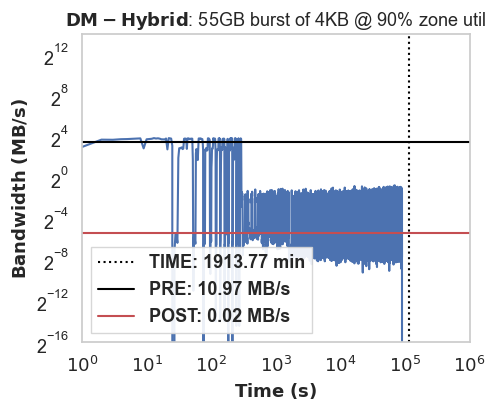

In [ ]:
#now plot the data with seaborn
#remove the grid and use white background
# sns.set_theme(style="whitegrid")
# plt.figure(figsize=(5, 4))
# plt.grid(False)
# ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped)
# plt.title(r"$\bf{DM-Hybrid}$: 55GB burst of 4KB @ 90% zone util", fontsize=13)

# common_yticks = [2**i for i in range(-16, 14, 2)]
# plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# # Custom formatter to display ticks as powers of 2
# def log2_format(y, pos):
#     return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# lowest_power_of_2 = 2 ** -16
# ax.set_ylim(lowest_power_of_2 , 2**14)
# ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
# #set x-axis to log scale
# ax.set_xscale('log', base=10)
# #set y-axis to log base 2 scale
# ax.set_yscale('log', base=2)
# plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# # Custom formatter to display ticks as powers of 10
# def log10_format(y, pos):
#     return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

# common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
# ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
# ax.set_xlim(10**0, 10**5)
# plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
# xmax = df_grouped.index.max()
# # Add a vertical line at the end of the experiment
# xmin = round(int(xmax)/60, 2)
# ax.axvline(x=xmax, color='black', linestyle=':', label='TIME: ' + str(xmin) + ' min')
# plt.xticks(fontsize=13)
# plt.yticks(fontsize=13)
# plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

# plt.axhline(y=average_mode2, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
# plt.axhline(y=average_mode1, color='r', linestyle='-', label='POST: ' + avg_bw_str1)
# plt.legend(loc='lower left', prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
#            shadow=False, framealpha=0.9, edgecolor='lightgray', fontsize=13 )

# plt.savefig('figs/4K_90Util_DMHybrid_BW.pdf', bbox_inches='tight',dpi=500)
# plt.show()

In [ ]:
"""Vectorized approach - fastest for most datasets"""

# Step 3: Determine time range
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Pre-compute all values vectorized
df_vec = df.copy()
df_vec['duration'] = df_vec['duration'].astype(float)
df_vec['start'] = df_vec['submission_time'].astype(int)
df_vec['end'] = df_vec['start'] + np.floor(df_vec['duration']).astype(int)

payload = 4096  # 4KB
df_vec['write_rate_per_ms'] = payload / np.maximum(df_vec['duration'], 1.0)
df_vec['floor_duration'] = np.floor(df_vec['duration']).astype(int)
df_vec['residue'] = payload - df_vec['write_rate_per_ms'] * df_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)

#Compare both approaches
print("Comparison of both approaches:")
print(data_written_ms.equals(data_written_ms_vec))  # Should return True if both methods yield the same result
print(data_written_ms_vec.equals(data_written_ms))  # Should return True if both methods yield the same result

#check if the dataframes are equal
print("DataFrames are equal:", data_written_ms.equals(data_written_ms_vec))  # Should return True if both methods yield the same result
print("DataFrames are equal:", data_written_ms_vec.equals(data_written_ms))  # Should return True if both methods yield the same result

##################################

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_grouped_vec.reset_index(inplace=True)
df_grouped_vec['cumulative_gb'] = df_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped_vec['data_written_bytes'] = df_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped_vec.describe())
print(df_grouped_vec.info())

####################

data_array_vec = df_grouped_vec['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array_vec)
# Get the cluster centers
cluster_centers_vec = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers_vec.sort()
# Calculate the average of each mode
average_mode1_vec = cluster_centers_vec[0]
average_mode2_vec = cluster_centers_vec[1]
print("Average1: " + str(average_mode1_vec))
print("Average2: " + str(average_mode2_vec))
avg_bw_str1 = str(round(average_mode1_vec*1024, 2)) + ' KB/s'
avg_bw_str2 = str(round(average_mode2_vec, 2)) + ' MB/s'

# ####################
# #now plot the data with seaborn
# #remove the grid and use white background
# sns.set_theme(style="whitegrid")
# plt.figure(figsize=(5, 4))
# plt.grid(False)
# ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped_vec, color= "#DC267F")
# plt.title(r"$\bf{HM-Hybrid}$: 5GB burst of 4KB @ 90% zone util", fontsize=13)

# common_yticks = [2**i for i in range(-16, 14, 2)]
# plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# # Custom formatter to display ticks as powers of 2
# def log2_format(y, pos):
#     return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# lowest_power_of_2 = 2 ** -16
# ax.set_ylim(lowest_power_of_2 , 2**14)
# ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
# #set x-axis to log scale
# ax.set_xscale('log', base=10)
# #set y-axis to log base 2 scale
# ax.set_yscale('log', base=2)
# plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# # Custom formatter to display ticks as powers of 10
# def log10_format(y, pos):
#     return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

# common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
# ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
# ax.set_xlim(10**0, 10**5)
# plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
# xmax = df_grouped_vec.index.max()
# # Add a vertical line at the end of the experiment
# xmin = round(int(xmax)/60, 2)
# ax.axvline(x=xmax, color='black', linestyle=':', label='TIME: ' + str(xmin) + ' min')
# plt.xticks(fontsize=13)
# plt.yticks(fontsize=13)
# plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

# plt.axhline(y=average_mode2_vec, color='black', linestyle='-', label='PRE: ' + avg_bw_str2)
# plt.axhline(y=average_mode1_vec, color='#009E73', linestyle='-', label='POST: ' + avg_bw_str1)
# plt.legend(
#     loc='upper left',
#     prop={'size':13, 'weight':'semibold'},
#     frameon=True,
#     fancybox=False,
#     shadow=False,
#     framealpha=0.9,
#     edgecolor='lightgray',
#     fontsize=13,
#     borderaxespad=0,   # Reduce padding between legend and axes
#     borderpad=0        # Reduce padding inside the legend box
# )

# plt.savefig('figs/4K_90Util_HMHybrid_BW.pdf', bbox_inches='tight',dpi=500)
# plt.show()

Comparison of both approaches:
False
False
DataFrames are equal: False
DataFrames are equal: False
               index  data_written_bytes  cumulative_gb
count  382664.000000       382664.000000  382664.000000
mean   191331.500000            0.013380       3.745704
std    110465.726041            0.684262       0.658065
min         0.000000            0.000000       0.021634
25%     95665.750000            0.001461       3.251368
50%    191331.500000            0.001514       3.768951
75%    286997.250000            0.001533       4.289370
max    382663.000000           72.227310       5.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382664 entries, 0 to 382663
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               382664 non-null  int64  
 1   data_written_bytes  382664 non-null  float64
 2   cumulative_gb       382664 non-null  float64
dtypes: float64(2), int64(1)
memory u

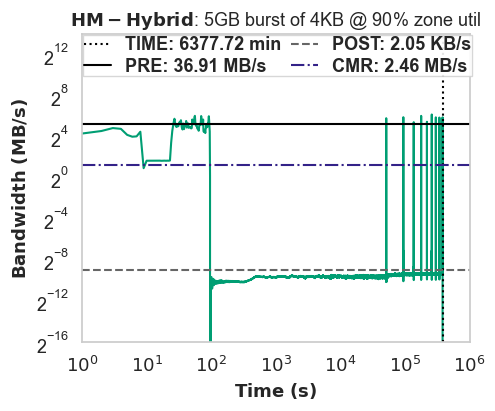

In [30]:
avg_bw_str1 = str(round(average_mode1_vec*1024, 2)) + ' KB/s'
avg_bw_str2 = str(round(average_mode2_vec, 2)) + ' MB/s'

####################
#now plot the data with seaborn
#remove the grid and use white background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))
plt.grid(False)
ax = sns.lineplot(x='index', y='data_written_bytes', data=df_grouped_vec, color=series_colors['hmhybrid'], linewidth=1.5)
plt.title(r"$\bf{HM-Hybrid}$: 5GB burst of 4KB @ 90% zone util", fontsize=13)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-16, 14, 2)])
# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

lowest_power_of_2 = 2 ** -16
ax.set_ylim(lowest_power_of_2 , 2**14)
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
#set x-axis to log scale
ax.set_xscale('log', base=10)
#set y-axis to log base 2 scale
ax.set_yscale('log', base=2)
plt.ylabel(r'$\bf{Bandwidth~(MB/s)}$', fontsize=13, fontweight='semibold')

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks,fontsize=13, fontweight='semibold')
xmax = df_grouped_vec.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='TIME: ' + str(xmin) + ' min')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel(r'$\bf{Time~(s)}$', fontsize=13, fontweight='semibold')

plt.axhline(y=average_mode2_vec, color=ref_line_colors['PRE'], linestyle=ref_line_styles['PRE'], label='PRE: ' + avg_bw_str2)
plt.axhline(y=average_mode1_vec, color=ref_line_colors['POST'], linestyle=ref_line_styles['POST'], label='POST: ' + avg_bw_str1)
plt.axhline(y=cmr_zipf_9010_4K_bw, color=ref_line_colors['CMR'], linestyle=ref_line_styles['CMR'], label='CMR: ' + str(cmr_zipf_9010_4K_bw) + ' MB/s')
plt.legend(
    loc='upper left',
    ncols=2,
    prop={'size':13, 'weight':'semibold'},  # Reduce font size
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=0.9,
    edgecolor='lightgray',
    fontsize=13,  # Reduce legend font size
    borderaxespad=0.05,   # Reduce padding between legend and axes
    borderpad=0.05,       # Reduce padding inside the legend box
    handlelength=1.5,       # Shorten legend handles
    labelspacing=0.2,     # Reduce vertical space between labels
    columnspacing=0.5     # Reduce horizontal space between columns
)

plt.savefig('figs/4K_90Util_HMHybrid_BW.pdf', bbox_inches='tight',dpi=500)
plt.show()